In [1]:
%matplotlib inline

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.data_preparation import load_and_prepare_data
from src.pipeline.feature_pipeline import FeaturePipeline

paths = load_paths()
logger = setup_logger(level="INFO")

SEED = 42

ROBUST_FEATURES = [
    "sz_all_mean",
    "sz_all_std",
    "sz_all_p25",
    "sz_all_median",
    "sz_all_p75",
    "sz_mean_max",
    "sz_mean_min",
    "sz_std_max",
    "sz_std_min",
]

In [2]:
df_all = load_and_prepare_data()

df_train = df_all[df_all["split"] == "train"].copy()
df_val = df_all[df_all["split"] == "val"].copy()
df_test = df_all[df_all["split"] == "test"].copy()

pipe = FeaturePipeline().fit(df_train)
all_model_features = pipe.model_feature_names()

for forbidden in ["source_capture_id", "source_file", "capture_id", "flow_id", "dataset", "split", "app", "connection_str"]:
    if forbidden in all_model_features:
        raise ValueError(f"Forbidden metadata leaked into model features: {forbidden}")

missing_robust = [f for f in ROBUST_FEATURES if f not in all_model_features]
if missing_robust:
    raise ValueError(f"Robust features missing from pipeline: {missing_robust}")

print("Datasets by split:")
print(pd.crosstab(df_all["split"], df_all["dataset"]))
print("\nUsing robust features:")
print(ROBUST_FEATURES)

2026-03-23 21:55:21 | INFO | ai-vpn-firewall | Loading VNAT (PCAP-based)...
2026-03-23 21:55:47 | INFO | ai-vpn-firewall | Loading ISCX (PCAP-based)...
2026-03-23 21:56:34 | INFO | ai-vpn-firewall | Loading USBVPN (JSON-based)...
2026-03-23 21:56:34 | INFO | ai-vpn-firewall | Metadata columns present for analysis only: ['source_capture_id', 'source_file']
2026-03-23 21:56:34 | INFO | ai-vpn-firewall | Multi-Domain Pool Created: (69558, 48)
2026-03-23 21:56:34 | INFO | ai-vpn-firewall | Datasets: {'usbvpn': 49650, 'iscx': 11801, 'vnat': 8107}
2026-03-23 21:56:34 | INFO | ai-vpn-firewall | Splits: {'train': 50271, 'test': 10540, 'val': 8747}
Datasets by split:
dataset  iscx  usbvpn  vnat
split                      
test     1634    8696   210
train    8388   34133  7750
val      1779    6821   147

Using robust features:
['sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min']


In [3]:
def metric_row(y_true, p, threshold=0.5):
    y_pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    recall = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0

    return {
        "roc_auc": roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan,
        "recall": recall,
        "precision": precision,
        "fpr": fpr,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "n_test": int(len(y_true)),
        "n_neg": int((y_true == 0).sum()),
        "n_pos": int((y_true == 1).sum()),
    }


def fit_xgb(df_fit, feature_cols):
    X = pipe.transform(df_fit)[feature_cols]
    y = df_fit["label"].astype(int).values

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        eval_metric="auc",
        random_state=SEED,
        n_jobs=4
    )
    model.fit(X, y)
    return model


def predict_df(model, df_eval, feature_cols):
    X = pipe.transform(df_eval)[feature_cols]
    p = model.predict_proba(X)[:, 1]
    y = df_eval["label"].astype(int).values
    return y, p


def find_val_threshold_for_fpr(y_val, p_val, target_fpr=0.01):
    order = np.argsort(p_val)[::-1]
    y_sorted = y_val[order]
    p_sorted = p_val[order]

    cum_fp = np.cumsum(y_sorted == 0)
    total_neg = int((y_sorted == 0).sum())

    if total_neg == 0:
        return 0.99

    fprs = cum_fp / total_neg
    valid_idx = np.where(fprs <= target_fpr)[0]
    if len(valid_idx) == 0:
        return 0.99
    return float(p_sorted[valid_idx[-1]])

In [4]:
print("="*80)
print("LEAVE-ONE-DATASET-OUT EVALUATION")
print("="*80)

dataset_names = ["vnat", "iscx", "usbvpn"]
rows = []

for held_out in dataset_names:
    train_df = df_train[df_train["dataset"] != held_out].copy()
    test_df = df_test[df_test["dataset"] == held_out].copy()
    val_df_local = df_val[df_val["dataset"] != held_out].copy()

    if train_df.empty or test_df.empty:
        continue

    model = fit_xgb(train_df, ROBUST_FEATURES)
    y_val_local, p_val_local = predict_df(model, val_df_local, ROBUST_FEATURES)
    thr = find_val_threshold_for_fpr(y_val_local, p_val_local, target_fpr=0.01)

    y_test_local, p_test_local = predict_df(model, test_df, ROBUST_FEATURES)
    row = metric_row(y_test_local, p_test_local, threshold=thr)
    row["train_on"] = "+".join(sorted(train_df["dataset"].unique()))
    row["test_on"] = held_out
    row["threshold"] = thr
    rows.append(row)

lood_df = pd.DataFrame(rows)
print(lood_df.to_string(index=False, float_format="%.4f"))

LEAVE-ONE-DATASET-OUT EVALUATION
 roc_auc  pr_auc  recall  precision    fpr   tn  fp   fn  tp  n_test  n_neg  n_pos    train_on test_on  threshold
  0.5143  0.0700  0.0000     0.0000 0.2538  147  50   13   0     210    197     13 iscx+usbvpn    vnat     0.4597
  0.4172  0.2447  0.1765     0.1972 0.1225 1225 171  196  42    1634   1396    238 usbvpn+vnat    iscx     0.1977
  0.1274  0.1452  0.0015     0.0114 0.0391 6386 260 2047   3    8696   6646   2050   iscx+vnat  usbvpn     0.5753


In [5]:
print("="*80)
print("DOMAIN-BALANCED TRAINING EXPERIMENT")
print("="*80)

def make_domain_balanced_train(df_train_in, seed=42):
    rng = np.random.default_rng(seed)
    out_parts = []

    datasets = sorted(df_train_in["dataset"].unique())
    per_dataset_counts = df_train_in["dataset"].value_counts()
    target_n = int(per_dataset_counts.min())

    for ds in datasets:
        sub = df_train_in[df_train_in["dataset"] == ds].copy()

        class_counts = sub["label"].value_counts()
        n_pos = int(class_counts.get(1, 0))
        n_neg = int(class_counts.get(0, 0))

        target_per_class = min(n_pos, n_neg, target_n // 2) if min(n_pos, n_neg) > 0 else min(target_n, len(sub))

        if target_per_class > 0 and n_pos > 0 and n_neg > 0:
            pos = sub[sub["label"] == 1].sample(n=target_per_class, random_state=seed, replace=False)
            neg = sub[sub["label"] == 0].sample(n=target_per_class, random_state=seed, replace=False)
            sub_bal = pd.concat([pos, neg], ignore_index=True)
        else:
            sub_bal = sub.sample(n=min(target_n, len(sub)), random_state=seed, replace=False)

        out_parts.append(sub_bal)

    out = pd.concat(out_parts, ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

baseline_train = df_train.copy()
balanced_train = make_domain_balanced_train(df_train, seed=SEED)

print("Baseline train counts:")
print(pd.crosstab(baseline_train["dataset"], baseline_train["label"]))

print("\nBalanced train counts:")
print(pd.crosstab(balanced_train["dataset"], balanced_train["label"]))

rows = []
for train_name, train_df_variant in [("baseline_pooled", baseline_train), ("dataset_balanced", balanced_train)]:
    model = fit_xgb(train_df_variant, ROBUST_FEATURES)
    y_val, p_val = predict_df(model, df_val, ROBUST_FEATURES)
    thr = find_val_threshold_for_fpr(y_val, p_val, target_fpr=0.01)

    y_test, p_test = predict_df(model, df_test, ROBUST_FEATURES)
    row = metric_row(y_test, p_test, threshold=thr)
    row["train_variant"] = train_name
    row["threshold"] = thr
    rows.append(row)

    for ds in sorted(df_test["dataset"].unique()):
        sub = df_test[df_test["dataset"] == ds].copy()
        y_ds, p_ds = predict_df(model, sub, ROBUST_FEATURES)
        r = metric_row(y_ds, p_ds, threshold=thr)
        r["train_variant"] = train_name
        r["dataset"] = ds
        r["threshold"] = thr
        rows.append(r)

domain_balanced_df = pd.DataFrame(rows)
print(domain_balanced_df.to_string(index=False, float_format="%.4f"))

DOMAIN-BALANCED TRAINING EXPERIMENT
Baseline train counts:
label        0     1
dataset             
iscx      6359  2029
usbvpn   29461  4672
vnat      7401   349

Balanced train counts:
label       0     1
dataset            
iscx     2029  2029
usbvpn   3875  3875
vnat      349   349
 roc_auc  pr_auc  recall  precision    fpr   tn  fp  fn   tp  n_test  n_neg  n_pos    train_variant  threshold dataset
  0.9932  0.9851  0.9509     0.9622 0.0104 8153  86 113 2188   10540   8239   2301  baseline_pooled     0.3840     NaN
  0.8735  0.7545  0.6092     0.9006 0.0115 1380  16  93  145    1634   1396    238  baseline_pooled     0.3840    iscx
  0.9990  0.9979  0.9917     0.9676 0.0102 6578  68  17 2033    8696   6646   2050  baseline_pooled     0.3840  usbvpn
  0.9828  0.7342  0.7692     0.8333 0.0102  195   2   3   10     210    197     13  baseline_pooled     0.3840    vnat
  0.9903  0.9791  0.9161     0.9608 0.0104 8153  86 193 2108   10540   8239   2301 dataset_balanced     0.8504     Na

In [6]:
print("="*80)
print("USBVPN LEAVE-ONE-SOURCE-FILE-OUT")
print("="*80)

usb = df_all[df_all["dataset"] == "usbvpn"].copy()

if "source_capture_id" not in usb.columns:
    raise ValueError("USBVPN missing source_capture_id; cannot run leave-one-source-file-out.")

source_ids = sorted(usb["source_capture_id"].dropna().unique().tolist())

rows = []
for held_out_source in source_ids:
    train_usb = usb[(usb["split"] == "train") & (usb["source_capture_id"] != held_out_source)].copy()
    test_usb = usb[usb["source_capture_id"] == held_out_source].copy()
    val_usb = usb[(usb["split"] == "val") & (usb["source_capture_id"] != held_out_source)].copy()

    if train_usb.empty or test_usb.empty:
        continue
    if test_usb["label"].nunique() < 2:
        continue

    model = fit_xgb(train_usb, ROBUST_FEATURES)
    y_val_usb, p_val_usb = predict_df(model, val_usb, ROBUST_FEATURES)
    thr = find_val_threshold_for_fpr(y_val_usb, p_val_usb, target_fpr=0.01)

    y_test_usb, p_test_usb = predict_df(model, test_usb, ROBUST_FEATURES)
    row = metric_row(y_test_usb, p_test_usb, threshold=thr)
    row["held_out_source_capture_id"] = held_out_source
    row["threshold"] = thr
    rows.append(row)

loso_df = pd.DataFrame(rows)
print(loso_df.to_string(index=False, float_format="%.4f"))

if not loso_df.empty:
    summary = loso_df[["roc_auc", "pr_auc", "recall", "precision", "fpr"]].agg(["mean", "std"])
    print("\nAggregate mean/std across held-out source files:")
    print(summary)

USBVPN LEAVE-ONE-SOURCE-FILE-OUT
 roc_auc  pr_auc  recall  precision    fpr    tn  fp   fn   tp  n_test  n_neg  n_pos held_out_source_capture_id  threshold
  0.8962  0.7903  0.9615     0.7576 0.2000    32   8    1   25      66     40     26                       mail     0.1800
  0.9670  0.8950  0.7500     0.8182 0.0417    46   2    3    9      60     48     12                       meet     0.2132
  0.9667  0.9360  0.7794     0.9932 0.0009 39570  35 1438 5080   46123  39605   6518              non_streaming     0.9216
  0.0941  0.3342  0.0000     0.0000 0.3226    21  10   30    0      61     31     30                        ssh     0.1727
  0.9989  0.9946  0.9931     0.9471 0.0116  2731  32    4  573    3340   2763    577                  streaming     0.1989

Aggregate mean/std across held-out source files:
       roc_auc    pr_auc    recall  precision       fpr
mean  0.784586  0.790019  0.696797   0.703204  0.115343
std   0.387829  0.265475  0.404055   0.404424  0.140899


DOMAIN DETECTOR + DE-FINGERPRINTING
full detector AUC: 1.0000
       feature  importance
  h_iat_all_00    0.674699
   iat_all_p25    0.215678
 h_size_all_01    0.037889
  h_iat_all_11    0.029742
  h_iat_all_01    0.013703
    sz_std_max    0.005920
  h_iat_all_08    0.005417
 h_size_all_00    0.005333
iat_all_median    0.002936
 h_size_all_02    0.002870
----------------------------------------
core detector AUC: 1.0000
       feature  importance
   sz_mean_max    0.709932
    sz_std_max    0.052656
    sz_all_p75    0.031578
  iat_mean_max    0.030892
   iat_std_min    0.026875
iat_all_median    0.026875
    sz_all_p25    0.024060
  iat_all_mean    0.016475
   iat_all_p75    0.014730
   iat_all_p25    0.014519
----------------------------------------
blind detector AUC: 0.9913
      feature  importance
  sz_mean_max    0.669015
   sz_std_max    0.111561
sz_all_median    0.080900
   sz_std_min    0.079496
  sz_mean_min    0.059029
----------------------------------------
 k_removed  

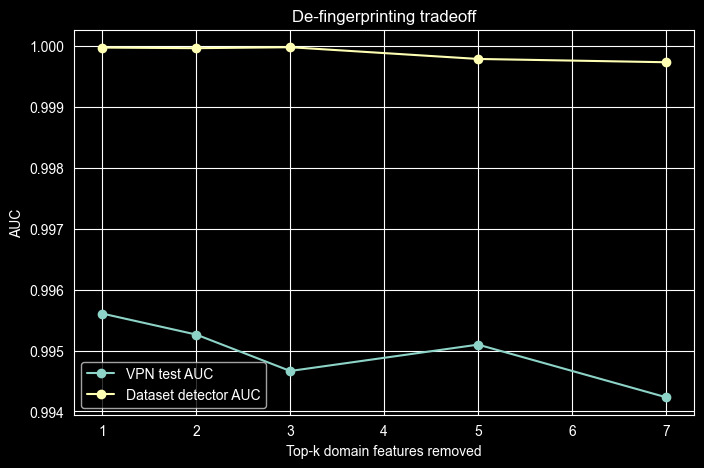

In [7]:
print("="*80)
print("DOMAIN DETECTOR + DE-FINGERPRINTING")
print("="*80)

FULL_FEATURES = pipe.model_feature_names()
CORE_FEATURES = [f for f in FULL_FEATURES if not f.startswith("h_")]
BLIND_FEATURES = [
    "sz_mean_max",
    "sz_mean_min",
    "sz_std_max",
    "sz_std_min",
    "sz_all_median",
]

def detector_auc(feature_cols):
    X_train = pipe.transform(df_train)[feature_cols]
    y_train_ds = (df_train["dataset"] == "usbvpn").astype(int).values

    X_test = pipe.transform(df_test)[feature_cols]
    y_test_ds = (df_test["dataset"] == "usbvpn").astype(int).values

    det = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric="auc",
        random_state=SEED,
        n_jobs=4
    )
    det.fit(X_train, y_train_ds)
    p_test = det.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test_ds, p_test)

    imp = pd.DataFrame({
        "feature": feature_cols,
        "importance": det.feature_importances_
    }).sort_values("importance", ascending=False)

    return auc, det, imp

for name, feats in [("full", FULL_FEATURES), ("core", CORE_FEATURES), ("blind", BLIND_FEATURES)]:
    auc, _, imp = detector_auc(feats)
    print(f"{name} detector AUC: {auc:.4f}")
    print(imp.head(10).to_string(index=False))
    print("-"*40)

core_auc, core_det, core_imp = detector_auc(CORE_FEATURES)

k_values = [1, 2, 3, 5, 7]
rows = []

for k in k_values:
    topk = core_imp["feature"].head(k).tolist()
    reduced = [f for f in CORE_FEATURES if f not in topk]

    model = fit_xgb(df_train, reduced)
    y_test_vpn, p_test_vpn = predict_df(model, df_test, reduced)
    vpn_auc = roc_auc_score(y_test_vpn, p_test_vpn)

    red_auc, _, _ = detector_auc(reduced)

    rows.append({
        "k_removed": k,
        "removed_features": ", ".join(topk),
        "n_remaining": len(reduced),
        "vpn_test_auc": vpn_auc,
        "dataset_detector_auc": red_auc,
    })

de_fingerprint_df = pd.DataFrame(rows)
print(de_fingerprint_df.to_string(index=False, float_format="%.4f"))

plt.figure(figsize=(8, 5))
plt.plot(de_fingerprint_df["k_removed"], de_fingerprint_df["vpn_test_auc"], marker="o", label="VPN test AUC")
plt.plot(de_fingerprint_df["k_removed"], de_fingerprint_df["dataset_detector_auc"], marker="o", label="Dataset detector AUC")
plt.xlabel("Top-k domain features removed")
plt.ylabel("AUC")
plt.title("De-fingerprinting tradeoff")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
print("="*80)
print("PERMUTATION IMPORTANCE BY DATASET")
print("="*80)

final_model = fit_xgb(df_train, ROBUST_FEATURES)

rows = []
rng = np.random.default_rng(SEED)

for ds in sorted(df_test["dataset"].unique()):
    sub = df_test[df_test["dataset"] == ds].copy()
    y_true, p_base = predict_df(final_model, sub, ROBUST_FEATURES)
    base_auc = roc_auc_score(y_true, p_base)

    X_sub = pipe.transform(sub)[ROBUST_FEATURES].copy()

    for feat in ROBUST_FEATURES:
        X_perm = X_sub.copy()
        X_perm[feat] = rng.permutation(X_perm[feat].values)
        p_perm = final_model.predict_proba(X_perm)[:, 1]
        auc_perm = roc_auc_score(y_true, p_perm)

        rows.append({
            "dataset": ds,
            "feature": feat,
            "base_auc": base_auc,
            "perm_auc": auc_perm,
            "auc_drop": base_auc - auc_perm,
        })

perm_df = pd.DataFrame(rows)
print(perm_df.sort_values(["dataset", "auc_drop"], ascending=[True, False]).to_string(index=False, float_format="%.4f"))

PERMUTATION IMPORTANCE BY DATASET
dataset       feature  base_auc  perm_auc  auc_drop
   iscx    sz_all_p25    0.8735    0.7370    0.1365
   iscx sz_all_median    0.8735    0.8183    0.0553
   iscx   sz_all_mean    0.8735    0.8202    0.0533
   iscx    sz_all_p75    0.8735    0.8241    0.0495
   iscx    sz_all_std    0.8735    0.8415    0.0321
   iscx   sz_mean_max    0.8735    0.8616    0.0120
   iscx    sz_std_max    0.8735    0.8668    0.0067
   iscx    sz_std_min    0.8735    0.8769   -0.0034
   iscx   sz_mean_min    0.8735    0.8829   -0.0094
 usbvpn    sz_all_p75    0.9990    0.9461    0.0529
 usbvpn    sz_all_p25    0.9990    0.9679    0.0311
 usbvpn sz_all_median    0.9990    0.9924    0.0066
 usbvpn   sz_mean_min    0.9990    0.9955    0.0035
 usbvpn    sz_std_min    0.9990    0.9977    0.0013
 usbvpn   sz_mean_max    0.9990    0.9984    0.0006
 usbvpn    sz_std_max    0.9990    0.9986    0.0004
 usbvpn    sz_all_std    0.9990    0.9989    0.0001
 usbvpn   sz_all_mean    0.999

In [9]:
print("="*80)
print("NEAREST-NEIGHBOR OVERLAP TEST")
print("="*80)

X_train = pipe.transform(df_train)[ROBUST_FEATURES].copy()
X_test = pipe.transform(df_test)[ROBUST_FEATURES].copy()

nn = NearestNeighbors(n_neighbors=5, metric="euclidean")
nn.fit(X_train)

distances, indices = nn.kneighbors(X_test)

train_dataset_arr = df_train["dataset"].values
test_dataset_arr = df_test["dataset"].values

rows = []
for i in range(len(df_test)):
    neigh_ds = train_dataset_arr[indices[i]]
    same_dataset_prop = np.mean(neigh_ds == test_dataset_arr[i])
    rows.append({
        "test_dataset": test_dataset_arr[i],
        "same_dataset_neighbor_prop": same_dataset_prop,
    })

nn_df = pd.DataFrame(rows)
print(nn_df.groupby("test_dataset")["same_dataset_neighbor_prop"].agg(["mean", "std", "count"]))

NEAREST-NEIGHBOR OVERLAP TEST
                  mean       std  count
test_dataset                           
iscx          0.898654  0.258709   1634
usbvpn        0.977806  0.104415   8696
vnat          0.936190  0.217697    210


PCA VISUALIZATION


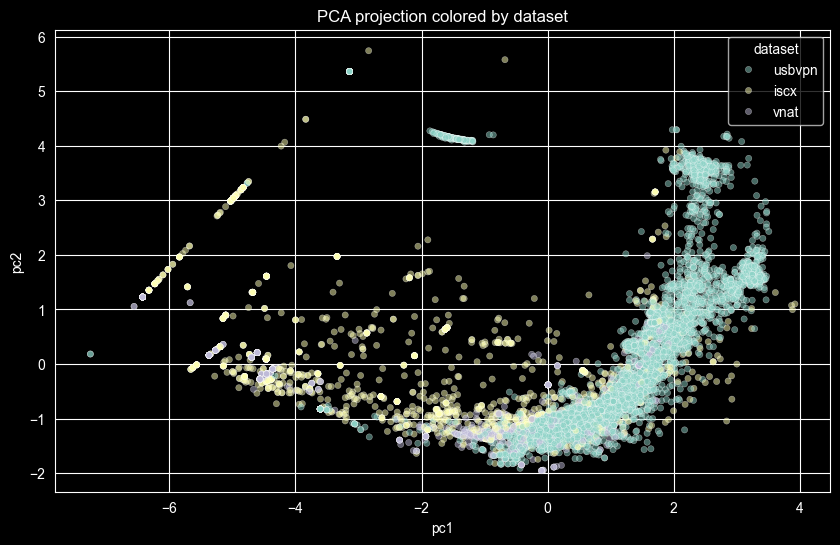

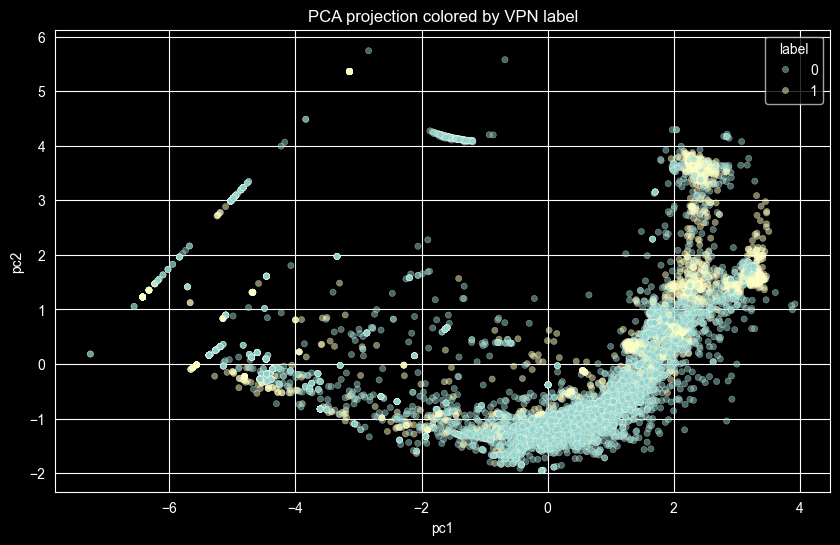

In [10]:
print("="*80)
print("PCA VISUALIZATION")
print("="*80)

X_all = pipe.transform(df_all)[ROBUST_FEATURES].copy()

pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(X_all)

viz_df = df_all[["dataset", "label", "split"]].copy()
viz_df["pc1"] = Z[:, 0]
viz_df["pc2"] = Z[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=viz_df.sample(min(10000, len(viz_df)), random_state=SEED),
    x="pc1", y="pc2",
    hue="dataset",
    alpha=0.5,
    s=20
)
plt.title("PCA projection colored by dataset")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=viz_df.sample(min(10000, len(viz_df)), random_state=SEED),
    x="pc1", y="pc2",
    hue="label",
    alpha=0.5,
    s=20
)
plt.title("PCA projection colored by VPN label")
plt.show()